
# Graph Fusion GNN Experiment

This notebook trains a **Graph Neural Network (GraphFusionNet)** using static and dynamic data features and evaluates its performance using t-SNE visualization.

---
### **Pipeline Overview**
1. Configuration  
2. Load dataset  
3. Label nodes  
4. Extract feature groups  
5. Normalize features  
6. Convert to tensors  
7. Create masks (train/val/test)  
8. Train model  
9. Evaluate and visualize embeddings


**GraphFusionNet-1 Architecture:**  
GraphFusionNet-1 is a dual-branch graph neural network designed to fuse node features from two distinct graphs sharing the same topology. Each input (`x1`, `x2`) passes through its own graph convolution layer (`gcn1_1`, `gcn1_2`) to produce hidden representations (`h1`, `h2`). These are combined using a learnable fusion weight α via a weighted sum \( h = αh_1 + (1 - α)h_2 \). The fused embedding `h` then passes through another pair of graph convolution layers (`gcn2_1`, `gcn2_2`), followed by a second fusion stage using the same α parameter to yield the final output. This design enables adaptive feature blending from multiple graph sources, enhancing joint representation learning.


**GraphFusionNet-1 Summary:**

- Designed for fusing static and dynamic graph data.  
- Inputs: node features `x1` (static), `x2` (dynamic), and shared `edge_index`.  
- Two parallel GCN layers extract features from both data sources. 
- Each branch has its own graph convolution layer (`gcn1_1` and `gcn1_2`).  
- Outputs from both branches (`h1`, `h2`) are combined using a learnable weight **α**.  
- Fusion equation:
  \( h = αh_1 + (1 - α)h_2 \).  
- A second GCN layer refines the fused representation into final output.  
- Returns either the fused embedding (`h`) or final output (`out`). 


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE
from torch_geometric.loader import DataLoader



from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *

c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [2]:
seed = 42
set_seed(seed)

num_epochs = 200

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'StaticDynamicGNN_adv_3'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
model_used = "M7_late_fusion_explainabilty"     

output_folder = f"results/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)

# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes.shape

(14640, 159)

# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [6]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [7]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [8]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [9]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [10]:
static_dt.shape

(14640, 11)

# Normalize features


# Smooth dynamic data

In [11]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

# global_min = dynamic_dt_smooth_log.min().min()
# global_max = dynamic_dt_smooth_log.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

dynamic_dt_smooth_log = pd.DataFrame(dynamic_dt_smooth_log)
static_dt = pd.DataFrame(static_dt)

# scaler = MinMaxScaler()

# static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

# Convert to tensors

In [12]:
dynamic_tensor = torch.tensor(dynamic_dt_smooth_log.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [13]:
print(dynamic_tensor.shape)
print(static_tensor.shape)

torch.Size([14640, 144])
torch.Size([14640, 11])


# Sliding Window approach

In [14]:
# # Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

# train_dataset = CrimeWindowPyGDataset(
# # train_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=0,
#     end_t=TRAIN_END
# )

# test_dataset = CrimeWindowPyGDataset(
# # test_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=TRAIN_END,
#     end_t=T
# )

# Inductive Learning

In [15]:
import torch

def filter_and_reindex(data, allowed_nodes):

    # ---- Step 1: mask nodes ----
    mask = torch.isin(data.node_ids, allowed_nodes)

    if mask.sum() == 0:
        return None

    # ---- Step 2: filter node features ----
    new_x_static = data.x_static[mask]
    new_x_dynamic = data.x_dynamic[mask]
    new_y = data.y[mask]

    # IMPORTANT: keep original node ids temporarily
    old_node_ids = data.node_ids[mask]

    # ---- Step 3: create mapping old → new index ----
    # Example: {5:0, 10:1, 20:2}
    unique_nodes = old_node_ids
    mapping = {int(old_id): i for i, old_id in enumerate(unique_nodes)}

    # ---- Step 4: filter edges ----
    src, dst = data.edge_index

    edge_mask = torch.isin(src, old_node_ids) & torch.isin(dst, old_node_ids)

    src = src[edge_mask]
    dst = dst[edge_mask]

    # ---- Step 5: reindex edges ----
    new_src = torch.tensor([mapping[int(s)] for s in src])
    new_dst = torch.tensor([mapping[int(d)] for d in dst])

    new_edge_index = torch.stack([new_src, new_dst], dim=0)

    # ---- Step 6: create new node ids (0...N-1) ----
    new_node_ids = torch.arange(len(unique_nodes))

    # ---- Step 7: update time_id ----
    new_time_id = data.time_id[mask]

    # ---- Step 8: return new Data ----
    new_data = data.clone()

    new_data.x_static = new_x_static
    new_data.x_dynamic = new_x_dynamic
    new_data.y = new_y
    new_data.edge_index = new_edge_index
    new_data.node_ids = new_node_ids   # ✅ reindexed
    new_data.time_id = new_time_id
    new_data.num_nodes = len(new_node_ids)

    return new_data

from torch.utils.data import Dataset

class InductiveWrapperDataset(Dataset):
    def __init__(self, base_dataset, allowed_nodes):
        self.base_dataset = base_dataset
        self.allowed_nodes = allowed_nodes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        data = self.base_dataset[idx]

        new_data = filter_and_reindex(data, self.allowed_nodes)

        # Handle rare empty case
        if new_data is None:
            return self.__getitem__((idx + 1) % len(self))

        return new_data
    
    import numpy as np

def split_nodes(num_nodes, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    nodes = np.arange(num_nodes)
    np.random.shuffle(nodes)

    split = int(train_ratio * num_nodes)

    train_nodes = torch.tensor(nodes[:split])
    test_nodes = torch.tensor(nodes[split:])

    return train_nodes, test_nodes

## Split nodes

In [16]:
train_nodes, test_nodes = split_nodes(static_tensor.shape[0])

## Compute normalization ONLY from TRAIN

Dynamic normalization

In [17]:
train_dynamic = dynamic_tensor[train_nodes][:, :TRAIN_END]

min_val = train_dynamic.min()
max_val = train_dynamic.max()

dynamic_tensor_norm = (dynamic_tensor - min_val) / (max_val - min_val + 1e-8)

In [18]:
dynamic_tensor.max()

tensor(3.8104)

Static normalization

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_static = static_tensor[train_nodes]

scaler.fit(train_static)

static_tensor_norm = torch.tensor(
    scaler.transform(static_tensor),
    dtype=torch.float32
)

Temporal Split

In [20]:
train_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)

# Inductive Split on nodes

In [21]:

# train_dataset = InductiveWrapperDataset(train_dataset, train_nodes)
# test_dataset = InductiveWrapperDataset(test_dataset, test_nodes)

In [22]:
sample = train_dataset[0]

print(sample.x_static.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 11])
tensor(14639) 14640


In [23]:
sample = test_dataset[0]

print(sample.x_dynamic.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 5])
tensor(14639) 14640


# Late Fusion Architecture

In [63]:
conv_layer = GATConv  # SAGEConv, GraphConv, GCNConv 

# Static & Dynamic Encoder with Fusion

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing

## Static Encoder

class StaticGCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.conv1 = conv_layer(in_dim, hidden_dim)
        self.conv2 = conv_layer(hidden_dim, hidden_dim)
        # self.act = nn.LeakyReLU(0.1)
        self.act = nn.ReLU()

    def forward(self, x_static, edge_index):
        x = self.conv1(x_static, edge_index)
        x = self.act(x)
        x = self.conv2(x, edge_index)
        return x  # [N, h]

## Dynamic Encoder
class DynamicGCNWindowEncoder(nn.Module):
    def __init__(self, window_size, hidden_dim):
        super().__init__()
        self.conv1 = conv_layer(window_size, hidden_dim)
        self.conv2 = conv_layer(hidden_dim, hidden_dim)
        # self.act = nn.LeakyReLU(0.1)
        self.act = nn.ReLU()


    def forward(self, x_dynamic, edge_index):
        x = self.conv1(x_dynamic, edge_index)
        x = self.act (x)
        x = self.conv2(x, edge_index)
        return x  # [N, h]

## Fuse Encoder outputs
class StaticDynamicGNN_Late_fusion(MessagePassing):
    def __init__(self, in_static, window_size, hidden_dim, out_dim, dropout=0.2):
        super().__init__()

        self.static_encoder = StaticGCNEncoder(
            in_dim=in_static,
            hidden_dim=hidden_dim
        )
        


        self.dynamic_encoder = DynamicGCNWindowEncoder(
            window_size=window_size,
            hidden_dim=hidden_dim
        )

        # self.act = nn.LeakyReLU(0.1)
        self.act = nn.ReLU()

        self.fusion_fc = nn.Linear(2 * hidden_dim, out_dim)


    def forward(self, x_static, x_dynamic, edge_index,  return_embedding = False, return_contribution = False):
        z_static = self.static_encoder(x_static, edge_index)    # [N, h]
        # z_static = self.act(z_static)
        z_dynamic = self.dynamic_encoder(x_dynamic, edge_index) # [N, h]
        
        z_fused = torch.cat([z_static, z_dynamic], dim=-1)      # [N, 2h]
        # z_fused = self.act(z_fused)
        out = self.fusion_fc(z_fused)                           # [N, 1]

        # if return_contribution:
        #     contrib = modality_contribution(z_static, z_dynamic)
        #     return out.squeeze(-1), contrib

        # if return_embedding:
        #     return z_fused
        return out.squeeze(-1), z_fused


# Late Fusioin Model

In [65]:
class CrimeForecastModel_late_fusion(nn.Module):
    def __init__(self, in_static, window_size, hidden_dim):
        super().__init__()
        self.late_fusion = StaticDynamicGNN_Late_fusion(
            in_static=in_static,
            window_size=window_size,
            hidden_dim=hidden_dim,
            out_dim=1
        )

    def forward(self, x_static, x_dynamic, edge_index, return_embedding = False, return_contribution = False):
        return self.late_fusion(x_static, x_dynamic, edge_index, return_embedding, return_contribution )


# Model initialization and optimizer

In [66]:
S = static_tensor.size(1)
model = CrimeForecastModel_late_fusion(
    in_static=S,
    window_size=W,
    hidden_dim=64
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [67]:
from torch.utils.data import Subset

# Chronological validation is taken only from the existing training windows.
# The untouched test_dataset is never used for checkpoint selection.
validation_fraction = 0.20
num_development_windows = len(train_dataset)
num_validation_windows = max(1, int(np.ceil(validation_fraction * num_development_windows)))
validation_start = num_development_windows - num_validation_windows

fit_dataset = Subset(train_dataset, range(0, validation_start))
validation_dataset = Subset(train_dataset, range(validation_start, num_development_windows))

train_loader = DataLoader(fit_dataset, batch_size=1, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Fit windows:", len(fit_dataset))
print("Validation windows:", len(validation_dataset))
print("Untouched test windows:", len(test_dataset))


Fit windows: 76
Validation windows: 19
Untouched test windows: 39


In [68]:
import copy

patience = 15
min_delta = 1e-6
best_validation_loss = float("inf")
best_epoch = 0
best_state = None
epochs_no_improve = 0

criterion = nn.MSELoss()

norm_hist = []
cond_norm_hist = []
grad_hist = []
train_loss_per_epoch = []
validation_loss_per_epoch = []
validation_metrics_per_epoch = []


@torch.no_grad()
def evaluate_late_fusion_loss(model, loader, criterion, device="cpu"):
    model.eval()
    total_squared_error = 0.0
    total_cases = 0
    for batch in loader:
        batch = batch.to(device)
        prediction, _ = model(batch.x_static, batch.x_dynamic, batch.edge_index)
        target = batch.y.float().view_as(prediction)
        loss = criterion(prediction, target)
        n = target.numel()
        total_squared_error += loss.item() * n
        total_cases += n
    return total_squared_error / max(total_cases, 1)


for epoch in range(num_epochs):
    train_loss = train_epoch_in(model, train_loader, optimizer, criterion, "cpu")
    validation_loss = evaluate_late_fusion_loss(
        model, validation_loader, criterion, device="cpu"
    )

    train_loss_per_epoch.append(train_loss)
    validation_loss_per_epoch.append(validation_loss)
    validation_metrics_per_epoch.append({"MSE": validation_loss})

    # Contribution diagnostics use one fitting batch and do not select the model.
    model.eval()
    with torch.no_grad():
        batch = next(iter(train_loader)).to("cpu")
        z_static = model.late_fusion.static_encoder(batch.x_static, batch.edge_index)
        z_dynamic = model.late_fusion.dynamic_encoder(batch.x_dynamic, batch.edge_index)
        norm_hist.append(modality_contribution(z_static, z_dynamic))
        cond_norm_hist.append(
            conditional_modality_contribution(z_static, z_dynamic, batch.x_dynamic)
        )

    grad_hist.append(gradient_modality_contribution(model, batch, criterion))

    if validation_loss < best_validation_loss - min_delta:
        best_validation_loss = validation_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch == 0 or (epoch + 1) % 10 == 0 or epoch + 1 == num_epochs:
        print(
            f"Epoch {epoch + 1:03d}/{num_epochs} | "
            f"Train MSE: {train_loss:.8f} | "
            f"Validation MSE: {validation_loss:.8f} | "
            f"Best: {best_validation_loss:.8f} (epoch {best_epoch}) | "
            f"Patience: {epochs_no_improve}/{patience}"
        )

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch + 1}; best epoch was {best_epoch}.")
        break

if best_state is None:
    raise RuntimeError("No validation checkpoint was created.")

model.load_state_dict(best_state)
num_trained_epochs = len(train_loss_per_epoch)

# Compatibility alias for old downstream cells. These are validation, not test, values.
test_loss_per_epoch = validation_metrics_per_epoch

print(
    f"Restored epoch {best_epoch} with validation MSE "
    f"{best_validation_loss:.8f}."
)


Epoch 001/200 | Train MSE: 0.00788017 | Validation MSE: 0.00387329 | Best: 0.00387329 (epoch 1) | Patience: 0/15
Epoch 010/200 | Train MSE: 0.00139022 | Validation MSE: 0.00197837 | Best: 0.00197837 (epoch 10) | Patience: 0/15
Epoch 020/200 | Train MSE: 0.00129707 | Validation MSE: 0.00183655 | Best: 0.00183655 (epoch 20) | Patience: 0/15
Epoch 030/200 | Train MSE: 0.00128005 | Validation MSE: 0.00180807 | Best: 0.00180807 (epoch 30) | Patience: 0/15
Epoch 040/200 | Train MSE: 0.00127255 | Validation MSE: 0.00179871 | Best: 0.00179871 (epoch 40) | Patience: 0/15
Epoch 050/200 | Train MSE: 0.00126866 | Validation MSE: 0.00179393 | Best: 0.00179393 (epoch 50) | Patience: 0/15
Epoch 060/200 | Train MSE: 0.00126647 | Validation MSE: 0.00179170 | Best: 0.00179170 (epoch 60) | Patience: 0/15
Epoch 070/200 | Train MSE: 0.00126560 | Validation MSE: 0.00179066 | Best: 0.00179066 (epoch 70) | Patience: 0/15
Epoch 080/200 | Train MSE: 0.00126474 | Validation MSE: 0.00178967 | Best: 0.00179066 (ep

In [69]:
metrics, preds_per_t, targets_per_t = evaluate_and_collect(
    model, test_loader, device = 'cpu'
)

print(metrics)
metrics



{'MSE': 0.0010155161144211888, 'RMSE': np.float64(0.03186716357665346), 'MAE': 0.01750670187175274, 'R2': 0.6499736905097961, 'huber': 0.0005077580572105944}


{'MSE': 0.0010155161144211888,
 'RMSE': np.float64(0.03186716357665346),
 'MAE': 0.01750670187175274,
 'R2': 0.6499736905097961,
 'huber': 0.0005077580572105944}

In [70]:
import pandas as pd

df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
df.to_csv(f"{output_folder}/metrics_results_{model_used}.csv", index=False, float_format="%.6f")

# Predicted Time Series Analysis

In [71]:
def plot_fluctuation_analysis(
    pred_matrix,
    targ_matrix,
    node,
    adj,
    max_hop=2,
    mode="mean",
    output_path=None,
    filename=None,
    show_correlation=True
):
    """
    pred_matrix : shape (T, N)
    targ_matrix : shape (T, N)
    node        : central node id
    adj         : adjacency dictionary
    max_hop     : number of hops
    mode        : "mean" or "all"
    show_correlation : display correlation values in plot
    """

    T = pred_matrix.shape[0]
    time = np.arange(T)

    plt.figure(figsize=(8, 5))

    # ---- Central target node ----
    central_tar = targ_matrix[:, node]
    plt.plot(
        time,
        central_tar,
        linewidth=3,
        color="green",
        label=f"Node {node} (original)"
    )

    # ---- Central predicted node ----
    central = pred_matrix[:, node]
    plt.plot(
        time,
        central,
        linewidth=3,
        color="red",
        label=f"Node {node} (predicted)"
    )
    

    hop_colors = plt.cm.viridis(np.linspace(0.3, 0.9, max_hop))

    correlations = []

    for hop in range(1, max_hop + 1):

        neighbors = get_neighbors(node, adj, order=hop)

        if len(neighbors) == 0:
            continue

        color = hop_colors[hop - 1]

        # Mean series for hop
        hop_series = pred_matrix[:, neighbors].mean(axis=1)

        # ---- Correlation ----
        corr = np.corrcoef(central, hop_series)[0, 1]
        correlations.append((hop, corr))

        if mode == "mean":

            plt.plot(
                time,
                hop_series,
                linewidth=2,
                linestyle="--",
                color=color,
                label=f"Mean {hop}-hop (ρ={corr:.2f})"
            )

        elif mode == "all":

            for n in neighbors:
                plt.plot(
                    time,
                    pred_matrix[:, n],
                    linewidth=1.5,
                    alpha=0.4,
                    color=color
                )

            # One legend entry
            plt.plot(
                [],
                [],
                color=color,
                linewidth=2,
                label=f"{hop}-hop (ρ={corr:.2f})"
            )

    plt.xlabel("Time Step")
    plt.ylabel("Crime Intensity")
    plt.title("Spatio-Temporal Crime Evolution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # # Optional: correlation text box
    # if show_correlation and correlations:
    #     corr_text = "\n".join(
    #         [f"{hop}-hop ρ = {corr:.3f}" for hop, corr in correlations]
    #     )
    #     plt.gcf().text(
    #         0.85, 0.75,
    #         corr_text,
    #         fontsize=10,
    #         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
    #     )

    if output_path:
        file_path = os.path.join(output_path, f"{filename}.png")
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    else:
        plt.show()
        plt.close()




# Selected Nodes

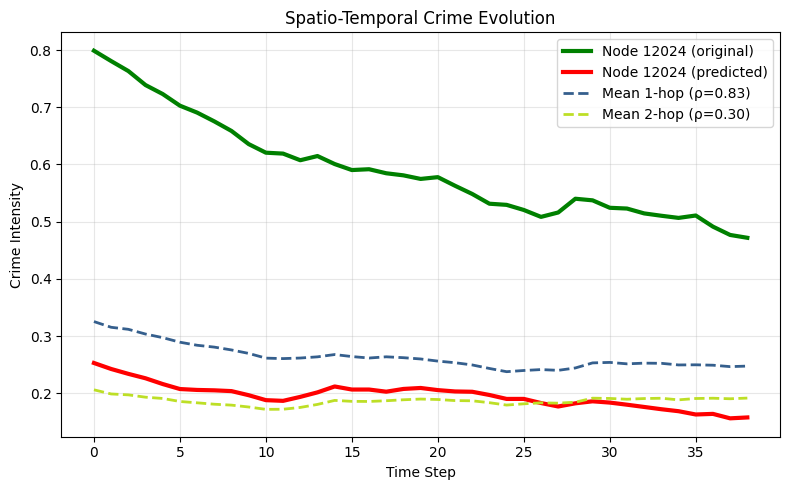

In [72]:
adj = build_adj(edge_index)
pred_matrix = np.stack(preds_per_t)
target_mat = np.stack(targets_per_t)
selected_node = 12024
plot_fluctuation_analysis(pred_matrix, target_mat, selected_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'node_{selected_node}_evolution_{model_used}')


# Choose High crime node

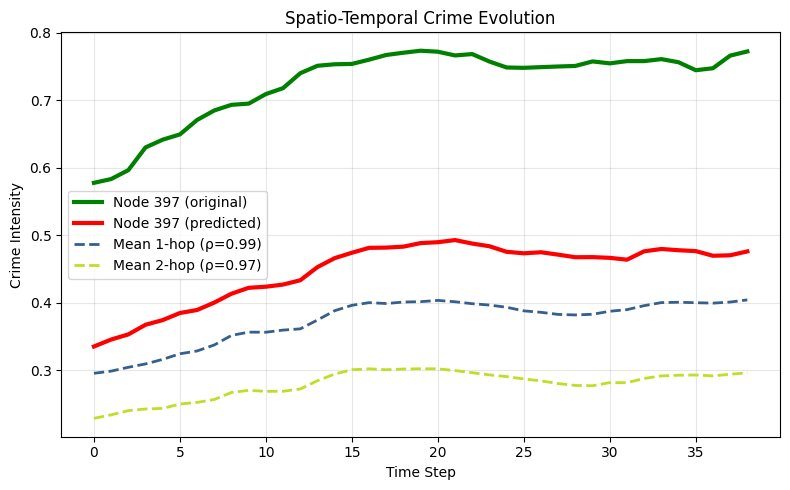

In [73]:
adj = build_adj(edge_index)
pred_matrix = np.stack(preds_per_t)
target_mat = np.stack(targets_per_t)

# Choose high-crime node
avg_pred_per_node = pred_matrix.mean(axis=0)
# high_node = np.argmax(avg_pred_per_node)
high_node = 397

neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_high_crime_node_{high_node}')


# Ablation Evaluation

In [74]:
static_only_loss = ablation_evaluate(model, test_loader, criterion, mode="static")
dynamic_only_loss = ablation_evaluate(model, test_loader, criterion, mode="dynamic")
print(f"Full model      : {metrics['MSE']:.4f}")
print(f"Static only     : {static_only_loss:.4f}")
print(f"Dynamic only    : {dynamic_only_loss:.4f}")

Full model      : 0.0010
Static only     : 0.0038
Dynamic only    : 0.0010


In [75]:
import pandas as pd

# Create results table
results = pd.DataFrame({
    "Model": ["Full model", "Static only", "Dynamic only"],
    "MSE": [
        metrics["MSE"],
        static_only_loss,
        dynamic_only_loss
    ]
})

# Save to CSV
results.to_csv(f"{output_folder}/ablation_results_{model_used}.csv", index=False)

print("Saved to ablation_results.csv")

Saved to ablation_results.csv


In [76]:
# def unpack_contribution(hist):
#     static = [h["static"] for h in hist]
#     dynamic = [h["dynamic"] for h in hist]
#     return static, dynamic


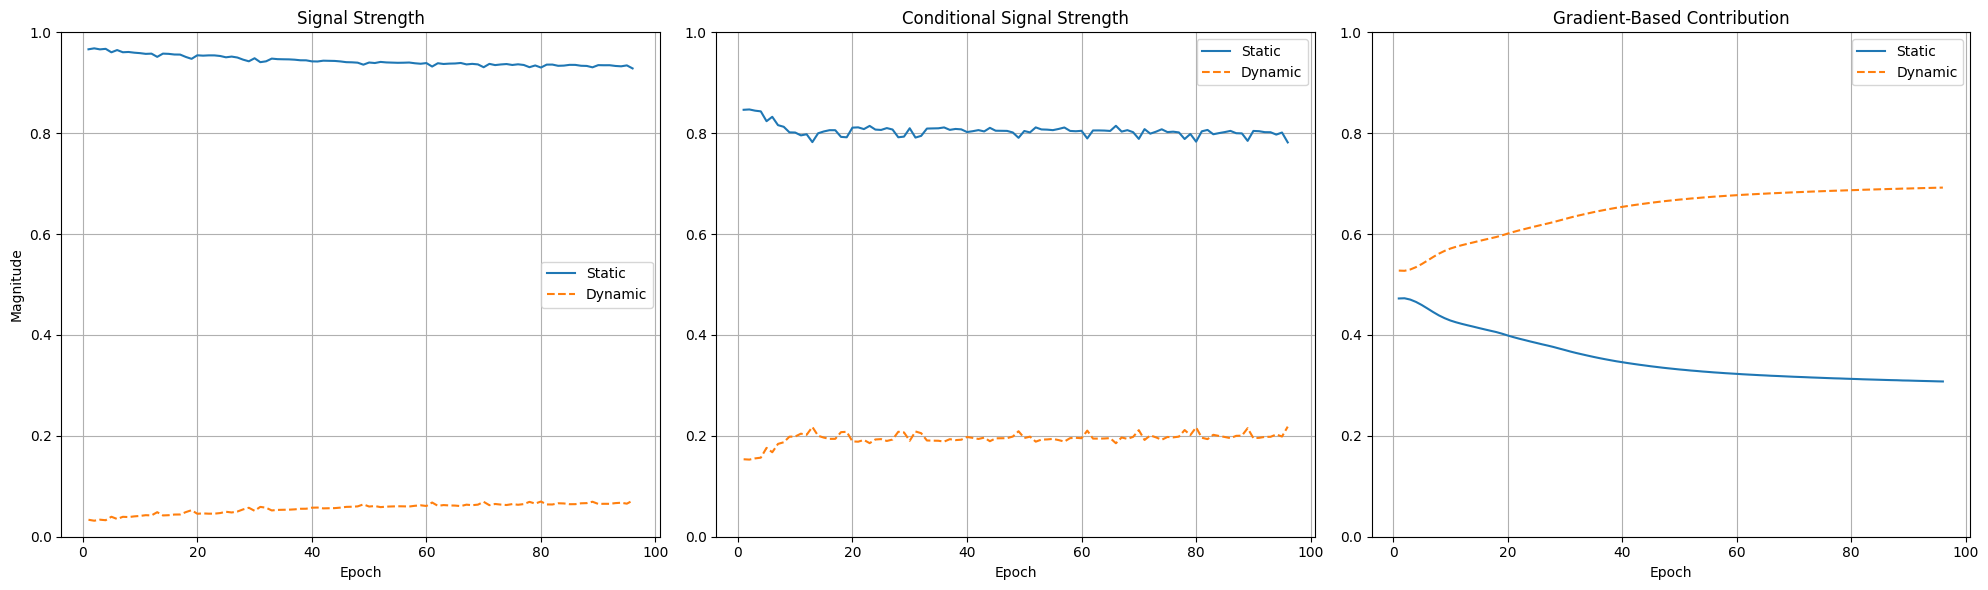

In [77]:
import matplotlib.pyplot as plt

epochs = range(1, len(norm_hist) + 1)

# unpack
norm_s, norm_d = unpack_contribution(norm_hist)
cond_s, cond_d = unpack_contribution(cond_norm_hist)
grad_s, grad_d = unpack_contribution(grad_hist)

plt.figure(figsize=(20, 6))

# ---- A0: naive norm
plt.subplot(1, 3, 1)
plt.plot(epochs, norm_s, label="Static")
plt.plot(epochs, norm_d, label="Dynamic", linestyle="--")
plt.title("Signal Strength")
plt.xlabel("Epoch")
plt.ylabel("Magnitude")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

# ---- A1: conditional norm
plt.subplot(1, 3, 2)
plt.plot(epochs, cond_s, label="Static")
plt.plot(epochs, cond_d, label="Dynamic", linestyle="--")
plt.title("Conditional Signal Strength")
plt.xlabel("Epoch")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

# ---- B: gradient-based
plt.subplot(1, 3, 3)
plt.plot(epochs, grad_s, label="Static")
plt.plot(epochs, grad_d, label="Dynamic", linestyle="--")
plt.title("Gradient-Based Contribution")
plt.xlabel("Epoch")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.show()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"Modality_Contribution.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


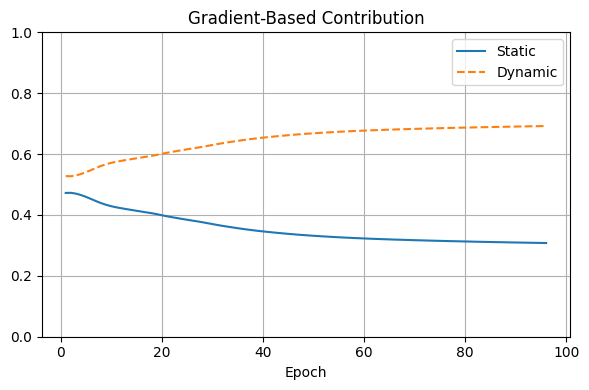

In [78]:
import matplotlib.pyplot as plt

epochs = range(1, len(norm_hist) + 1)

# unpack
norm_s, norm_d = unpack_contribution(norm_hist)
cond_s, cond_d = unpack_contribution(cond_norm_hist)
grad_s, grad_d = unpack_contribution(grad_hist)

plt.figure(figsize=(6, 4))

# ---- A0: naive norm
# plt.subplot(1, 3, 1)
# plt.plot(epochs, norm_s, label="Static")
# plt.plot(epochs, norm_d, label="Dynamic", linestyle="--")
# plt.title("Signal Strength")
# plt.xlabel("Epoch")
# plt.ylabel("Magnitude")
# plt.ylim(0, 1)
# plt.legend()
# plt.grid(True)

# # ---- A1: conditional norm
# plt.subplot(1, 3, 2)
# plt.plot(epochs, cond_s, label="Static")
# plt.plot(epochs, cond_d, label="Dynamic", linestyle="--")
# plt.title("Conditional Signal Strength")
# plt.xlabel("Epoch")
# plt.ylim(0, 1)
# plt.legend()
# plt.grid(True)

# # ---- B: gradient-based
# plt.subplot(1, 3, 3)
plt.plot(epochs, grad_s, label="Static")
plt.plot(epochs, grad_d, label="Dynamic", linestyle="--")
plt.title("Gradient-Based Contribution")
plt.xlabel("Epoch")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.show()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"Modality_gradient_Contribution_{model_used}.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


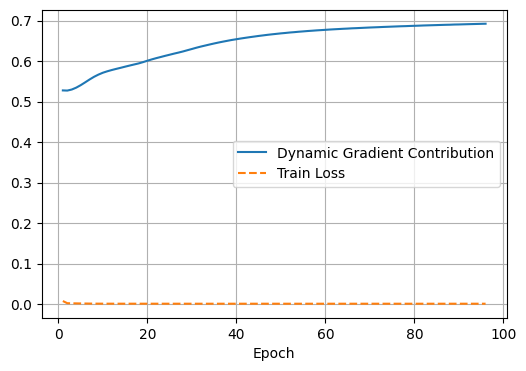

In [79]:
plt.figure(figsize=(6,4))
plt.plot(epochs, grad_d, label="Dynamic Gradient Contribution")
plt.plot(epochs, train_loss_per_epoch, label="Train Loss", linestyle="--")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [80]:
# alpha_self_history = []
# alpha_neigh_history = []
# train_loss_per_epoch = []
# test_loss_per_epoch = []
# static_hist, dynamic_hist = [], []

# for epoch in range(30):
#     train_loss = train_epoch_in(model, train_loader, optimizer, criterion, "cpu")
#     # # alpha_self = model.gnn.alpha_self.item()
#     # alpha_neigh = model.gnn.alpha_neigh.item()

#     # alpha_self_history.append(alpha_self)
#     # alpha_neigh_history.append(alpha_neigh)

#     ##______________ Contribution___________________________________
#     with torch.no_grad():
#         for batch in train_loader:
#             _, contrib = model(
#                 batch.x_static,
#                 batch.x_dynamic,
#                 batch.edge_index,
#                 return_contribution=True
#             )
#             break  # one batch is enough
    
#     static_hist.append(contrib["static"])
#     dynamic_hist.append(contrib["dynamic"])
    
#     ##______________ Contribution___________________________________

#     train_loss_per_epoch.append(train_loss)

#     test_loss = evaluate_in(model, test_loader, "cpu")
#     test_loss_per_epoch.append(test_loss)

#     print(
#         f"Epoch {epoch:02d} | "
#         f"Train: {train_loss:.4f} | "
#         # f"Self → Static: {alpha_self:.3f}, Dynamic: {1-alpha_self:.3f} | "
#         # f"Neigh → Static: {alpha_neigh:.3f}, Dynamic: {1-alpha_neigh:.3f} | "
#         f"Test: {test_loss:.4f}"
#     )

In [81]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,5))
# plt.plot(static_hist, label="Static contribution", linewidth=2)
# plt.plot(dynamic_hist, label="Dynamic contribution", linewidth=2)
# plt.xlabel("Epoch")
# plt.ylabel("Relative contribution")
# plt.title("Static vs Dynamic Contribution (Late Fusion)")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [82]:
test_loss_per_epoch

[{'MSE': 0.0038732896607957387},
 {'MSE': 0.003534388409829453},
 {'MSE': 0.0032065472394031914},
 {'MSE': 0.002931629442364762},
 {'MSE': 0.002674033516086638},
 {'MSE': 0.0024405599841357847},
 {'MSE': 0.002243804837282943},
 {'MSE': 0.0021026337053626776},
 {'MSE': 0.0020244116833629576},
 {'MSE': 0.001978372615811072},
 {'MSE': 0.0019504741557236564},
 {'MSE': 0.001931948703713715},
 {'MSE': 0.0019173770530247374},
 {'MSE': 0.0018977025940426085},
 {'MSE': 0.0018839370949487936},
 {'MSE': 0.0018709048408230668},
 {'MSE': 0.0018581524430038897},
 {'MSE': 0.001851700828410685},
 {'MSE': 0.0018406583572198685},
 {'MSE': 0.0018365515310219244},
 {'MSE': 0.0018303854280690614},
 {'MSE': 0.0018232129514217377},
 {'MSE': 0.0018198895084328558},
 {'MSE': 0.0018202304337663871},
 {'MSE': 0.0018165506128417818},
 {'MSE': 0.0018148442950883979},
 {'MSE': 0.001814408717971099},
 {'MSE': 0.0018114022003780854},
 {'MSE': 0.0018096400277787133},
 {'MSE': 0.0018080714538595394},
 {'MSE': 0.0018074

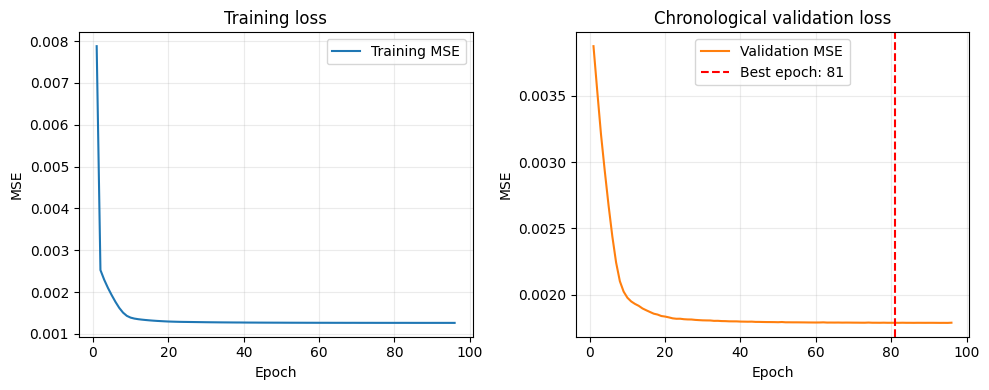

In [83]:
from matplotlib.ticker import MaxNLocator

epochs = np.arange(1, len(train_loss_per_epoch) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epochs, train_loss_per_epoch, label="Training MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Training loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(epochs, validation_loss_per_epoch, label="Validation MSE", color="tab:orange")
axes[1].axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch: {best_epoch}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Chronological validation loss")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
file_path = os.path.join(output_folder, f"train_validation_loss_{model_used}.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


In [84]:
# Use an actual complete test window. The model was trained with W dynamic lags,
# so using only the last three columns would cause an input-dimension mismatch.
embedding_batch = next(iter(test_loader)).to("cpu")
model.eval()
with torch.no_grad():
    _, embeddings = model(
        embedding_batch.x_static,
        embedding_batch.x_dynamic,
        embedding_batch.edge_index,
        return_embedding=True,
    )
print(f"Node embeddings shape: {embeddings.shape}")


Node embeddings shape: torch.Size([14640, 128])


In [85]:
tsne = TSNE(n_components=2, random_state=seed)
emb_2d = tsne.fit_transform(embeddings.detach().cpu().numpy())

tsne_result = pd.DataFrame(emb_2d)
tsne_result.to_csv(f"{output_folder}/tsne_output_{model_used}_{type_graph_conv}_{architecture}.csv", index=False)

In [86]:
def plot_embedding(emb_2d, filename= 'embedding', output_path = None):
    df_emb = pd.DataFrame(emb_2d, columns=['x', 'y'])

    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_emb, x='x', y='y', palette='Set1')
    # Save or show
    if output_path:
        file_path = os.path.join(output_path, f"{filename}.{save_format}")
        plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        plt.show()
        plt.close()

In [87]:
def plot_embedding_label(emb_2d, crime_label_tensor, filename= 'embedding', output_path = None):
    df_emb = pd.DataFrame(emb_2d, columns=['x', 'y'])
    df_emb['label'] = crime_label_tensor

    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_emb, x='x', y='y', hue='label', palette='Set1')
    # Save or show
    if output_path:
        file_path = os.path.join(output_path, f"{filename}.{save_format}")
        plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        plt.show()
        plt.close()

C:\Users\waqar\AppData\Local\Temp\ipykernel_11376\2259634616.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_emb, x='x', y='y', palette='Set1')


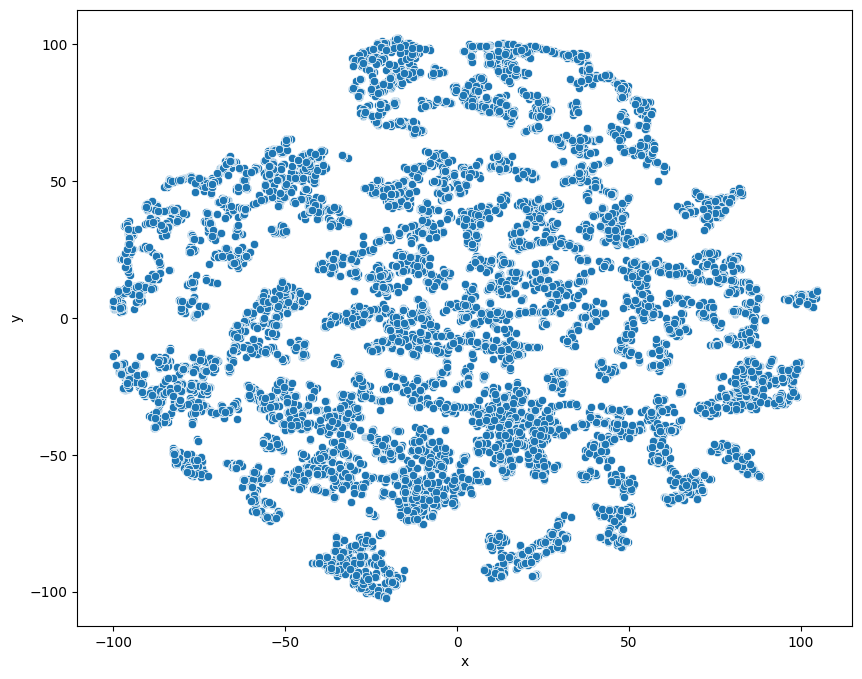

In [88]:
plot_embedding(emb_2d, filename= f'embedding_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)

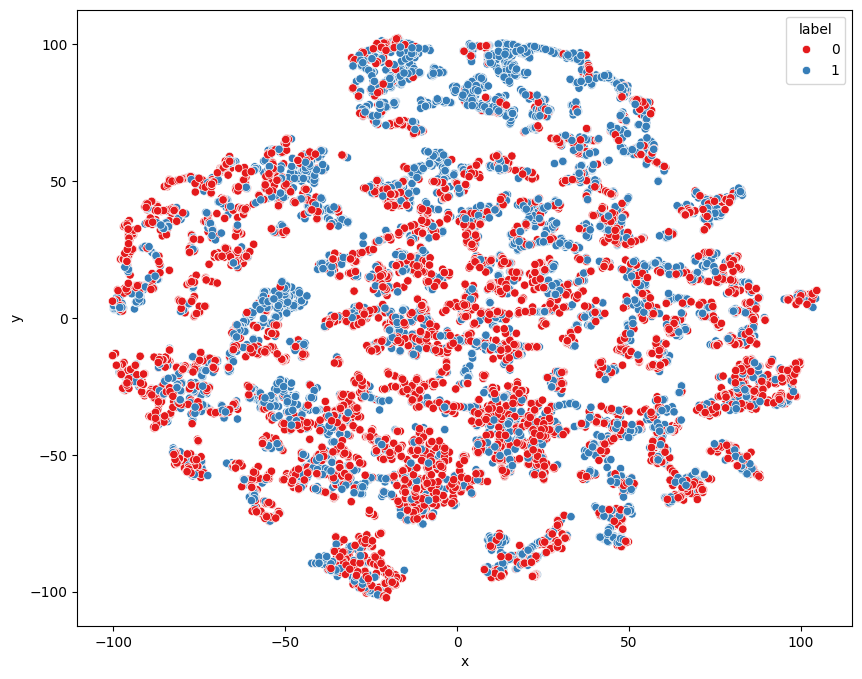

In [89]:
plot_embedding_label(emb_2d, crime_label_col, filename= f'embedding_class_label_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)


# Complete late-fusion analysis suite

This appendix aligns the late-fusion baseline with the M11, original-GMU and GMU–GNN analyses wherever a scientifically valid counterpart exists. Preprocessing and model architecture remain unchanged. The only earlier changes are methodological corrections: chronological validation replaces test-based early stopping, the best checkpoint is deep-copied, and the embedding cell uses the complete dynamic window expected by the model.

## What is and is not comparable

| Analysis used for gated models | Late-fusion counterpart | Eligibility |
|---|---|---|
| Raw gate distribution, entropy and saturation | None | **Not applicable: no gate exists** |
| Feature-wise gate specialization | Fusion-layer branch weights and effective channel contributions | Applicable as an analogue, not a gate |
| Gate–crime association | Effective branch-share association with crime | Applicable as an analogue |
| Effective gated activation | Exact branch output before bias | Applicable |
| Self-versus-neighbor gates | None | **Not applicable** |
| Gate intervention/shuffling | Latent branch removal and branch reassignment | Applicable as a branch-faithfulness test |
| Modality ablation | Input and latent-branch ablation | Applicable |
| Spatial/temporal stability | Effective branch-share stability | Applicable |
| Prediction error association | Branch-share versus error | Applicable |
| Input permutation importance | Static features and temporal lags | Applicable |
| Time-cluster bootstrap | Prediction and branch-share intervals | Applicable |
| Graph reliance | Edge-removal intervention | Applicable: both encoders are GNNs |

Late fusion concatenates independently graph-encoded static and dynamic representations and applies one linear output layer. It contains no probability-valued modality selector. Therefore, branch contributions must not be called “gates.”

## A. Evaluation and rich node-time collection

For the scalar linear output, the prediction can be decomposed exactly as

$$hat y = W_s z_s + W_d z_d + b.$$

The two terms before the bias are the signed static and dynamic branch outputs. Their absolute magnitudes provide a local branch-strength diagnostic. Cancellation can occur when the signed terms have opposite directions, so both signed values and normalized absolute shares are retained.

In [90]:
import math
import contextlib
import warnings

try:
    from scipy.stats import pearsonr, spearmanr
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    warnings.warn("SciPy is unavailable; p-values will be skipped.")


def _expand_late_metadata(value, n, fallback, device):
    if value is None:
        value = torch.as_tensor(fallback, device=device)
    value = value.reshape(-1)
    if value.numel() == 1 and n > 1:
        value = value.repeat(n)
    if value.numel() != n:
        raise ValueError(f"Metadata length {value.numel()} does not match {n} cases.")
    return value


@torch.no_grad()
def collect_late_fusion_explainability(model, loader, device="cpu"):
    model.eval()
    frames = []
    static_vectors, dynamic_vectors, fused_vectors = [], [], []
    predictions_per_time, targets_per_time = [], []

    fusion = model.late_fusion.fusion_fc
    hidden_dim = fusion.in_features // 2
    static_weight = fusion.weight[:, :hidden_dim]
    dynamic_weight = fusion.weight[:, hidden_dim:]
    bias = fusion.bias.reshape(1) if fusion.bias is not None else torch.zeros(1, device=device)

    for step, batch in enumerate(loader):
        batch = batch.to(device)
        z_static = model.late_fusion.static_encoder(batch.x_static, batch.edge_index)
        z_dynamic = model.late_fusion.dynamic_encoder(batch.x_dynamic, batch.edge_index)
        z_fused = torch.cat([z_static, z_dynamic], dim=-1)

        static_output = (z_static * static_weight).sum(dim=1)
        dynamic_output = (z_dynamic * dynamic_weight).sum(dim=1)
        prediction = static_output + dynamic_output + bias
        target = batch.y.float().view_as(prediction)
        n = target.numel()

        node_ids = _expand_late_metadata(
            getattr(batch, "node_ids", None), n, torch.arange(n, device=device), device
        )
        time_ids = _expand_late_metadata(
            getattr(batch, "time_id", None), n, step, device
        )

        static_abs = static_output.abs()
        dynamic_abs = dynamic_output.abs()
        static_share = static_abs / (static_abs + dynamic_abs + 1e-12)

        frames.append(pd.DataFrame({
            "node_id": node_ids.cpu().numpy(),
            "time_id": time_ids.cpu().numpy(),
            "input_crime": batch.x_dynamic.mean(dim=1).cpu().numpy(),
            "target_crime": target.cpu().numpy(),
            "prediction": prediction.cpu().numpy(),
            "residual": (target - prediction).cpu().numpy(),
            "absolute_error": (target - prediction).abs().cpu().numpy(),
            "static_branch_output": static_output.cpu().numpy(),
            "dynamic_branch_output": dynamic_output.cpu().numpy(),
            "static_branch_abs": static_abs.cpu().numpy(),
            "dynamic_branch_abs": dynamic_abs.cpu().numpy(),
            "static_effective_share": static_share.cpu().numpy(),
            "dynamic_effective_share": (1.0-static_share).cpu().numpy(),
            "static_embedding_norm": torch.linalg.vector_norm(z_static, dim=1).cpu().numpy(),
            "dynamic_embedding_norm": torch.linalg.vector_norm(z_dynamic, dim=1).cpu().numpy(),
        }))
        static_vectors.append(z_static.cpu())
        dynamic_vectors.append(z_dynamic.cpu())
        fused_vectors.append(z_fused.cpu())
        predictions_per_time.append(prediction.cpu().numpy())
        targets_per_time.append(target.cpu().numpy())

    frame = pd.concat(frames, ignore_index=True)
    error = frame["prediction"].to_numpy() - frame["target_crime"].to_numpy()
    mse = float(np.mean(error**2))
    target = frame["target_crime"].to_numpy()
    denominator = float(np.sum((target-target.mean())**2))
    metrics_local = {
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": float(np.mean(np.abs(error))),
        "R2": float(1.0-np.sum(error**2)/denominator) if denominator > 0 else np.nan,
    }
    details = {
        "frame": frame,
        "z_static": torch.cat(static_vectors).numpy(),
        "z_dynamic": torch.cat(dynamic_vectors).numpy(),
        "z_fused": torch.cat(fused_vectors).numpy(),
        "predictions_per_time": predictions_per_time,
        "targets_per_time": targets_per_time,
    }
    return metrics_local, details


late_metrics, late_details = collect_late_fusion_explainability(model, test_loader, "cpu")
late_frame = late_details["frame"]
display(pd.DataFrame([late_metrics]))
display(late_frame.head())
late_frame.to_csv(os.path.join(output_folder, "late_fusion_rich_explainability.csv"), index=False)


,MSE,RMSE,MAE,R2
0,0.001016,0.031867,0.017507,0.649974


,node_id,time_id,input_crime,target_crime,prediction,residual,absolute_error,static_branch_output,dynamic_branch_output,static_branch_abs,dynamic_branch_abs,static_effective_share,dynamic_effective_share,static_embedding_norm,dynamic_embedding_norm
0,0,100,0.126909,0.136371,0.073509,0.062862,0.062862,0.059385,0.083112,0.059385,0.083112,0.416747,0.583253,1.683949,0.256552
1,1,100,0.109170,0.097192,0.076113,0.021079,0.021079,0.059009,0.086091,0.059009,0.086091,0.406681,0.593319,1.675789,0.241981
2,2,100,0.161374,0.125887,0.062104,0.063783,0.063783,0.060811,0.070280,0.060811,0.070280,0.463886,0.536114,1.746461,0.203653
3,3,100,0.096176,0.097884,0.056241,0.041644,0.041644,0.060073,0.065154,0.060073,0.065154,0.479713,0.520287,1.635107,0.208666
4,4,100,0.014133,0.041428,0.014247,0.027181,0.027181,0.059697,0.023538,0.059697,0.023538,0.717210,0.282790,1.625810,0.078150


## B. Gate analyses — not applicable

This model has no sigmoid/softmax gate, no learned modality probability and no complementary weights constrained to sum to one. Consequently, gate mean, gate entropy, gate saturation, shuffled-gate tests and feature-wise gate specialization are mathematically undefined.

The following sections analyze **effective branch output** instead. This is the appropriate late-fusion analogue, but it must not be described as a gate analysis.

## C. Global and conditional branch contribution

This analysis asks how much each encoded branch contributes to the final scalar output after accounting for the learned fusion-layer weights. A share near 0.5 means similar absolute branch-output magnitudes; it does not mean that the model has learned a 50/50 gate.

,mean_static_effective_share,mean_dynamic_effective_share,mean_signed_static_output,mean_signed_dynamic_output,mean_static_embedding_norm,mean_dynamic_embedding_norm
0,0.66886,0.33114,0.06,0.03867,1.6067,0.13214


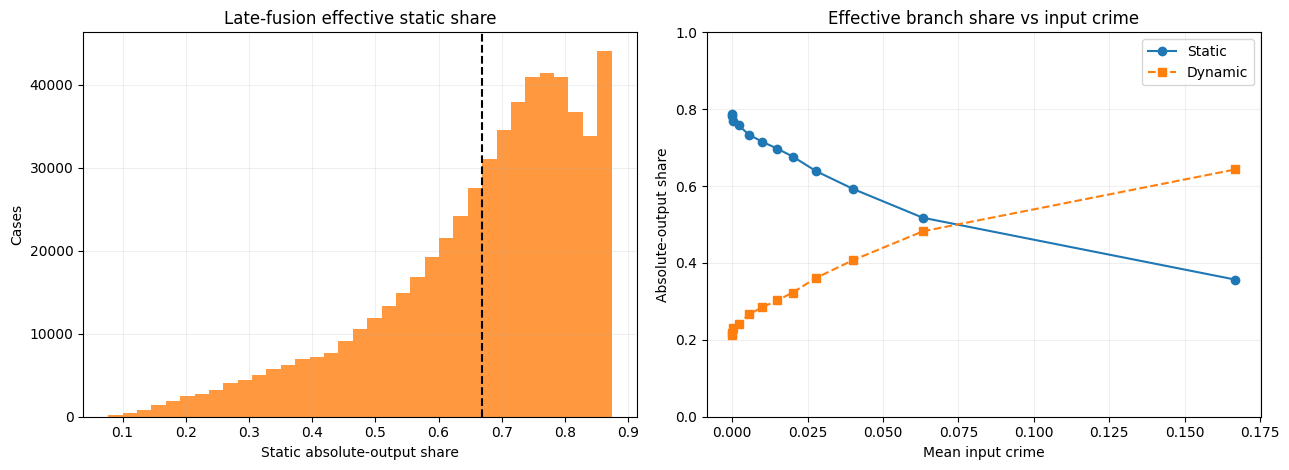

In [91]:
def association_stats_late(x, y):
    x, y = np.asarray(x), np.asarray(y)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return {"pearson_r":np.nan,"pearson_p":np.nan,"spearman_rho":np.nan,"spearman_p":np.nan}
    if SCIPY_AVAILABLE:
        pr, sr = pearsonr(x, y), spearmanr(x, y)
        return {"pearson_r":float(pr[0]),"pearson_p":float(pr[1]),
                "spearman_rho":float(sr[0]),"spearman_p":float(sr[1])}
    return {"pearson_r":float(np.corrcoef(x,y)[0,1]),"pearson_p":np.nan,
            "spearman_rho":np.nan,"spearman_p":np.nan}


def binned_summary_late(frame, x_col, y_col, bins=12):
    work = frame[[x_col,y_col]].replace([np.inf,-np.inf],np.nan).dropna().copy()
    work["bin"] = pd.qcut(work[x_col], q=bins, duplicates="drop")
    out = work.groupby("bin", observed=True).agg(
        mean_x=(x_col,"mean"), mean_y=(y_col,"mean"),
        std_y=(y_col,"std"), count=(y_col,"size")
    ).reset_index(drop=True)
    out["ci95"] = 1.96*out["std_y"] / np.sqrt(out["count"].clip(lower=1))
    return out


late_global_contribution = pd.DataFrame([{
    "mean_static_effective_share": late_frame["static_effective_share"].mean(),
    "mean_dynamic_effective_share": late_frame["dynamic_effective_share"].mean(),
    "mean_signed_static_output": late_frame["static_branch_output"].mean(),
    "mean_signed_dynamic_output": late_frame["dynamic_branch_output"].mean(),
    "mean_static_embedding_norm": late_frame["static_embedding_norm"].mean(),
    "mean_dynamic_embedding_norm": late_frame["dynamic_embedding_norm"].mean(),
}])
display(late_global_contribution.round(5))

summary = binned_summary_late(late_frame, "input_crime", "static_effective_share")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].hist(late_frame["static_effective_share"], bins=35, color="tab:orange", alpha=0.8)
axes[0].axvline(late_frame["static_effective_share"].mean(), color="black", linestyle="--")
axes[0].set(title="Late-fusion effective static share", xlabel="Static absolute-output share", ylabel="Cases")
axes[1].plot(summary["mean_x"], summary["mean_y"], marker="o", label="Static")
axes[1].plot(summary["mean_x"], 1-summary["mean_y"], marker="s", linestyle="--", label="Dynamic")
axes[1].fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"], summary["mean_y"]+summary["ci95"], alpha=0.15)
axes[1].set(title="Effective branch share vs input crime", xlabel="Mean input crime", ylabel="Absolute-output share", ylim=(0,1))
axes[1].legend()
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig(os.path.join(output_folder,"late_fusion_effective_contribution.png"),dpi=300,bbox_inches="tight"); plt.show()
late_global_contribution.to_csv(os.path.join(output_folder,"late_fusion_global_contribution.csv"),index=False)


## D. Fusion-layer channel specialization

There is no feature-wise gate. Instead, this section inspects the final linear layer’s static and dynamic weights and the average effective magnitude $|w_k z_k|$ of every latent channel. Large weights alone are insufficient because a channel can have a large coefficient but rarely activate.

,channel,static_weight,dynamic_weight,static_mean_abs_effect,dynamic_mean_abs_effect
0,0,-0.063550,0.117914,0.028947,3.260572e-03
38,38,-0.056469,0.149091,0.027980,2.471459e-03
41,41,0.045899,-0.039929,0.023442,6.367468e-07
16,16,0.051616,0.006605,0.019014,6.372165e-05
50,50,0.060795,-0.000907,0.019012,3.380456e-10
7,7,-0.057843,-0.026947,0.017532,8.598736e-10
49,49,0.073531,-0.087073,0.016305,0.000000e+00
33,33,0.077473,-0.014521,0.015000,0.000000e+00
46,46,0.042356,-0.030227,0.013515,1.541898e-09
48,48,-0.064922,0.153308,0.012919,3.801087e-03


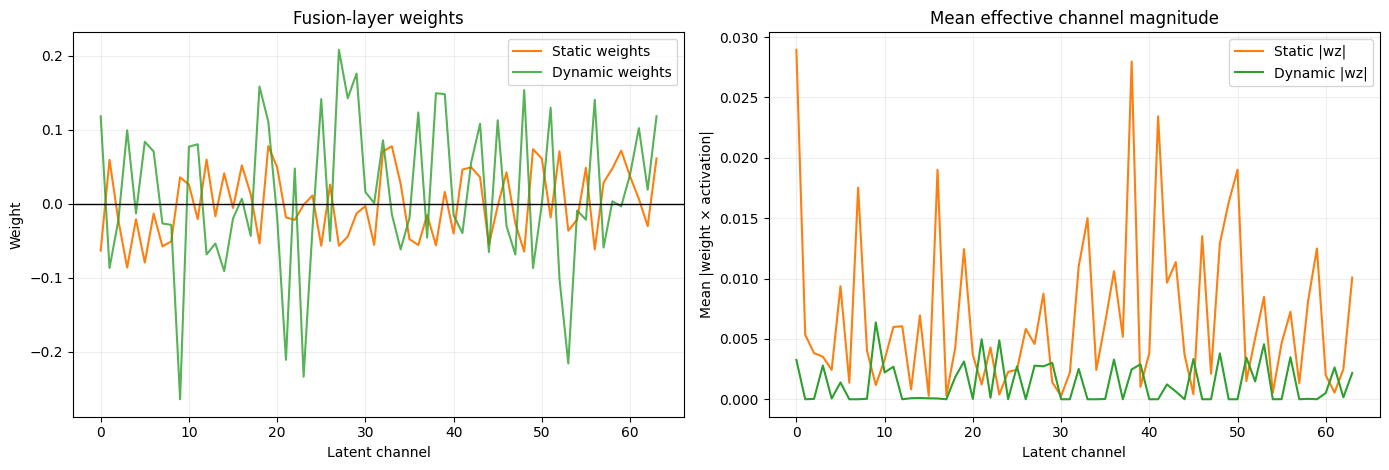

In [92]:
fusion_weight = model.late_fusion.fusion_fc.weight.detach().cpu().numpy().reshape(-1)
hidden_dim = fusion_weight.size // 2
static_weight = fusion_weight[:hidden_dim]
dynamic_weight = fusion_weight[hidden_dim:]
static_channel_effect = np.mean(np.abs(late_details["z_static"] * static_weight[None,:]), axis=0)
dynamic_channel_effect = np.mean(np.abs(late_details["z_dynamic"] * dynamic_weight[None,:]), axis=0)

channel_table = pd.DataFrame({
    "channel": np.arange(hidden_dim),
    "static_weight": static_weight,
    "dynamic_weight": dynamic_weight,
    "static_mean_abs_effect": static_channel_effect,
    "dynamic_mean_abs_effect": dynamic_channel_effect,
})
display(channel_table.sort_values("static_mean_abs_effect",ascending=False).head(10))

fig, axes = plt.subplots(1,2,figsize=(14,4.8))
axes[0].plot(static_weight,label="Static weights",color="tab:orange")
axes[0].plot(dynamic_weight,label="Dynamic weights",color="tab:green",alpha=0.8)
axes[0].axhline(0,color="black",linewidth=1); axes[0].set(title="Fusion-layer weights",xlabel="Latent channel",ylabel="Weight"); axes[0].legend()
axes[1].plot(static_channel_effect,label="Static |wz|",color="tab:orange")
axes[1].plot(dynamic_channel_effect,label="Dynamic |wz|",color="tab:green")
axes[1].set(title="Mean effective channel magnitude",xlabel="Latent channel",ylabel="Mean |weight × activation|"); axes[1].legend()
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig(os.path.join(output_folder,"late_fusion_channel_specialization.png"),dpi=300,bbox_inches="tight"); plt.show()
channel_table.to_csv(os.path.join(output_folder,"late_fusion_channel_specialization.csv"),index=False)


## E. Branch association with input and future crime

Pearson measures linear association and Spearman measures monotonic association. These are descriptive relationships, not causal effects. They answer whether the relative static/dynamic output balance changes systematically with crime intensity.

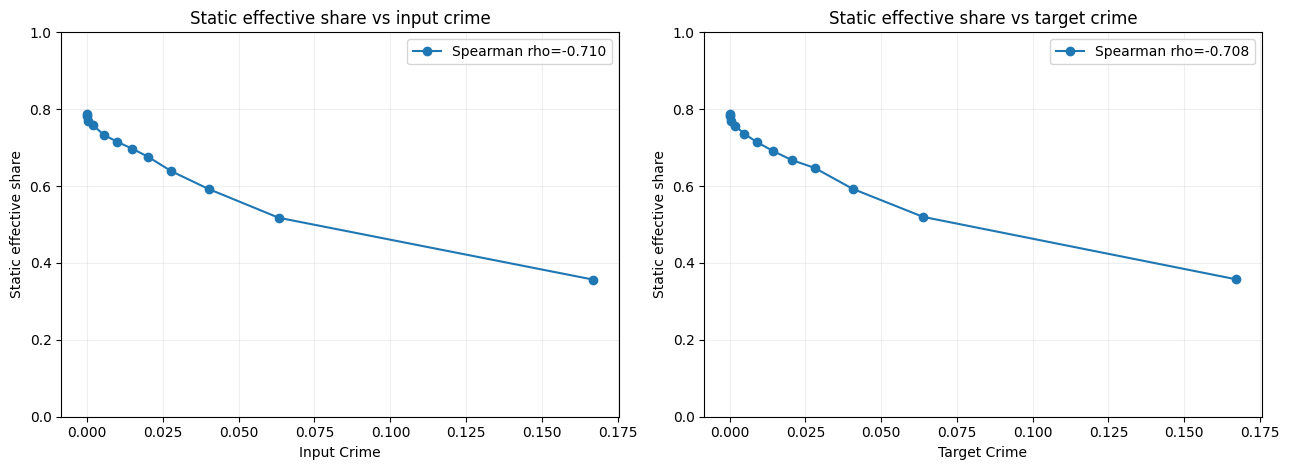

,crime_variable,pearson_r,pearson_p,spearman_rho,spearman_p
0,input_crime,-0.69595,0.0,-0.71012,0.0
1,target_crime,-0.69573,0.0,-0.70799,0.0


In [93]:
late_assoc_rows=[]
fig,axes=plt.subplots(1,2,figsize=(13,4.8))
for ax,x_col in zip(axes,["input_crime","target_crime"]):
    stats=association_stats_late(late_frame[x_col],late_frame["static_effective_share"])
    late_assoc_rows.append({"crime_variable":x_col,**stats})
    summary=binned_summary_late(late_frame,x_col,"static_effective_share")
    ax.plot(summary["mean_x"],summary["mean_y"],marker="o")
    ax.fill_between(summary["mean_x"],summary["mean_y"]-summary["ci95"],summary["mean_y"]+summary["ci95"],alpha=0.2)
    ax.set(title=f"Static effective share vs {x_col.replace('_',' ')}",xlabel=x_col.replace('_',' ').title(),ylabel="Static effective share",ylim=(0,1))
    ax.legend([f"Spearman rho={stats['spearman_rho']:.3f}"])
    ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig(os.path.join(output_folder,"late_fusion_crime_associations.png"),dpi=300,bbox_inches="tight"); plt.show()
late_fusion_crime_associations=pd.DataFrame(late_assoc_rows)
display(late_fusion_crime_associations.round(5))
late_fusion_crime_associations.to_csv(os.path.join(output_folder,"late_fusion_crime_associations.csv"),index=False)


## F. Self-versus-neighbor modality roles — not applicable

Each branch uses a GAT encoder, but the architecture returns only one static embedding and one dynamic embedding after graph aggregation. It does not expose separate modality controls for the focal node and incoming neighbor messages. Therefore, M11’s self-gate versus neighbor-gate analysis is not defined for this late-fusion model.

The graph intervention below can test whether propagation matters overall, but it cannot recover separate modality-selection roles.

## G. Spatial and temporal stability of effective branch balance

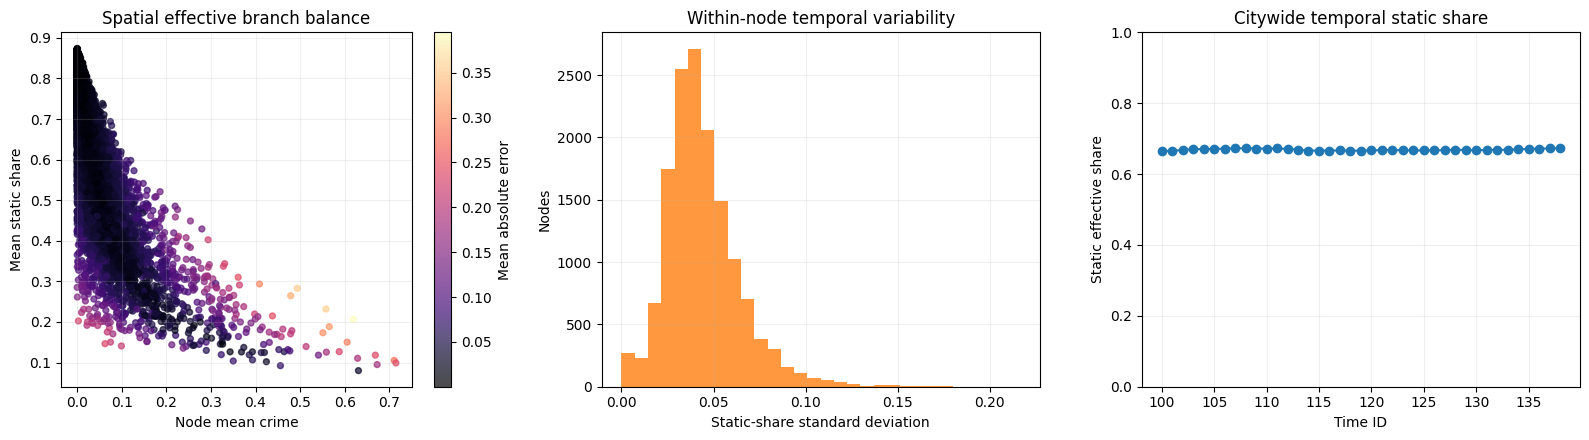

In [94]:
late_node_stability=late_frame.groupby("node_id").agg(
    static_share_mean=("static_effective_share","mean"),static_share_std=("static_effective_share","std"),
    mean_crime=("input_crime","mean"),mean_absolute_error=("absolute_error","mean")
).reset_index()
late_time_stability=late_frame.groupby("time_id").agg(
    static_share_mean=("static_effective_share","mean"),static_share_std=("static_effective_share","std"),mean_crime=("input_crime","mean")
).reset_index()

fig,axes=plt.subplots(1,3,figsize=(16,4.5))
sc=axes[0].scatter(late_node_stability["mean_crime"],late_node_stability["static_share_mean"],c=late_node_stability["mean_absolute_error"],cmap="magma",s=18,alpha=0.7)
fig.colorbar(sc,ax=axes[0],label="Mean absolute error")
axes[0].set(title="Spatial effective branch balance",xlabel="Node mean crime",ylabel="Mean static share")
axes[1].hist(late_node_stability["static_share_std"].dropna(),bins=30,color="tab:orange",alpha=0.8)
axes[1].set(title="Within-node temporal variability",xlabel="Static-share standard deviation",ylabel="Nodes")
axes[2].plot(late_time_stability["time_id"],late_time_stability["static_share_mean"],marker="o")
axes[2].set(title="Citywide temporal static share",xlabel="Time ID",ylabel="Static effective share",ylim=(0,1))
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig(os.path.join(output_folder,"late_fusion_spatial_temporal_stability.png"),dpi=300,bbox_inches="tight"); plt.show()
late_node_stability.to_csv(os.path.join(output_folder,"late_fusion_node_stability.csv"),index=False)
late_time_stability.to_csv(os.path.join(output_folder,"late_fusion_time_stability.csv"),index=False)


## H. Effective branch balance versus prediction error

This shows whether static-heavy or dynamic-heavy cases tend to be more difficult. Association does not establish that changing the balance would reduce error; the intervention tests below provide stronger functional evidence.

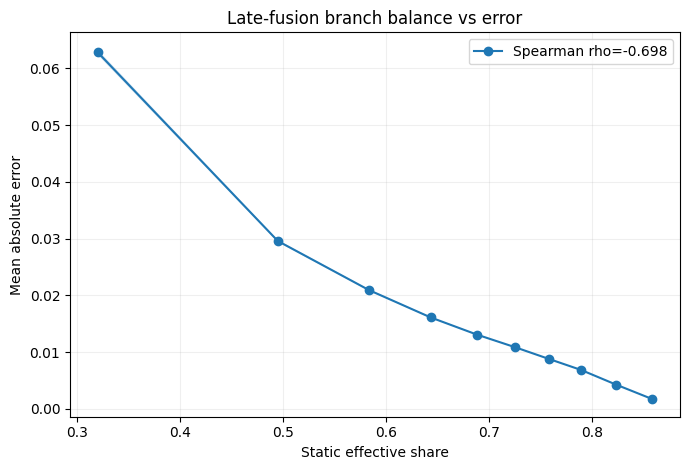

,pearson_r,pearson_p,spearman_rho,spearman_p
0,-0.64977,0.0,-0.69802,0.0


In [95]:
late_error_stats=association_stats_late(late_frame["static_effective_share"],late_frame["absolute_error"])
summary=binned_summary_late(late_frame,"static_effective_share","absolute_error",bins=10)
plt.figure(figsize=(7,4.8)); plt.plot(summary["mean_x"],summary["mean_y"],marker="o")
plt.fill_between(summary["mean_x"],summary["mean_y"]-summary["ci95"],summary["mean_y"]+summary["ci95"],alpha=0.2)
plt.xlabel("Static effective share"); plt.ylabel("Mean absolute error"); plt.title("Late-fusion branch balance vs error")
plt.legend([f"Spearman rho={late_error_stats['spearman_rho']:.3f}"]); plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder,"late_fusion_share_error.png"),dpi=300,bbox_inches="tight"); plt.show()
late_error_association=pd.DataFrame([late_error_stats]); display(late_error_association.round(5))
late_error_association.to_csv(os.path.join(output_folder,"late_fusion_share_error.csv"),index=False)


## I. Latent-branch intervention faithfulness

The two encoders are kept fixed while one latent branch is removed or reassigned across nodes. Shuffling preserves a branch’s activation distribution but breaks its case-specific assignment. This is the closest late-fusion counterpart to shuffled-gate faithfulness, but it tests branch representations rather than gates.

,intervention,MSE,RMSE,MAE,delta_MSE_vs_learned,relative_MSE_change_percent
0,Learned branches,0.001016,0.031867,0.017507,0.000000,0.000000
1,Static branch removed,0.004555,0.067490,0.061232,0.003539,348.535901
2,Dynamic branch removed,0.004393,0.066277,0.038152,0.003377,332.557759
3,Static branch shuffled,0.001018,0.031911,0.017545,0.000003,0.276446
4,Dynamic branch shuffled,0.004816,0.069397,0.038450,0.003800,374.233622


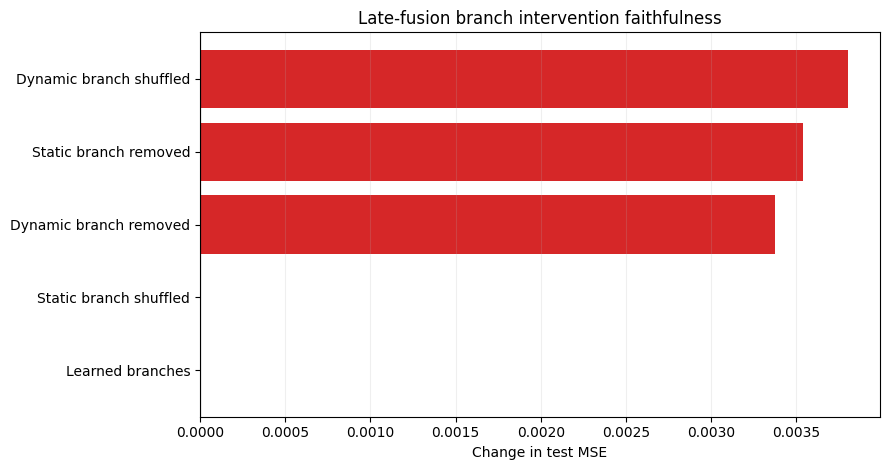

In [96]:
@torch.no_grad()
def evaluate_late_branch_intervention(model,loader,device="cpu",mode="learned",random_seed=42):
    model.eval(); predictions=[]; targets=[]
    for step,batch in enumerate(loader):
        batch=batch.to(device)
        zs=model.late_fusion.static_encoder(batch.x_static,batch.edge_index)
        zd=model.late_fusion.dynamic_encoder(batch.x_dynamic,batch.edge_index)
        if mode=="static_removed": zs=torch.zeros_like(zs)
        elif mode=="dynamic_removed": zd=torch.zeros_like(zd)
        elif mode=="static_shuffled":
            g=torch.Generator(device=device); g.manual_seed(random_seed+step)
            zs=zs[torch.randperm(zs.shape[0],generator=g,device=device)]
        elif mode=="dynamic_shuffled":
            g=torch.Generator(device=device); g.manual_seed(random_seed+10000+step)
            zd=zd[torch.randperm(zd.shape[0],generator=g,device=device)]
        elif mode!="learned": raise ValueError(mode)
        prediction=model.late_fusion.fusion_fc(torch.cat([zs,zd],dim=-1)).squeeze(-1)
        predictions.append(prediction.cpu()); targets.append(batch.y.float().view_as(prediction).cpu())
    prediction=torch.cat(predictions).numpy(); target=torch.cat(targets).numpy(); error=prediction-target; mse=float(np.mean(error**2))
    return {"MSE":mse,"RMSE":float(np.sqrt(mse)),"MAE":float(np.mean(np.abs(error)))}

rows=[]
for label,mode in [("Learned branches","learned"),("Static branch removed","static_removed"),("Dynamic branch removed","dynamic_removed"),("Static branch shuffled","static_shuffled"),("Dynamic branch shuffled","dynamic_shuffled")]:
    rows.append({"intervention":label,**evaluate_late_branch_intervention(model,test_loader,"cpu",mode,seed)})
late_branch_interventions=pd.DataFrame(rows)
baseline=late_branch_interventions.loc[late_branch_interventions.intervention=="Learned branches","MSE"].iloc[0]
late_branch_interventions["delta_MSE_vs_learned"]=late_branch_interventions["MSE"]-baseline
late_branch_interventions["relative_MSE_change_percent"]=100*late_branch_interventions["delta_MSE_vs_learned"]/(baseline+1e-12)
display(late_branch_interventions.round(6))
plot_df=late_branch_interventions.sort_values("delta_MSE_vs_learned")
plt.figure(figsize=(9,4.8)); plt.barh(plot_df["intervention"],plot_df["delta_MSE_vs_learned"],color=["tab:green" if x<=0 else "tab:red" for x in plot_df["delta_MSE_vs_learned"]])
plt.axvline(0,color="black"); plt.xlabel("Change in test MSE"); plt.title("Late-fusion branch intervention faithfulness"); plt.grid(axis="x",alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder,"late_fusion_branch_interventions.png"),dpi=300,bbox_inches="tight"); plt.show()
late_branch_interventions.to_csv(os.path.join(output_folder,"late_fusion_branch_interventions.csv"),index=False)


## J. Model-agnostic input permutation importance

Each original static feature or dynamic lag is permuted across nodes while all weights remain fixed. Increasing MSE indicates predictive reliance. Correlated inputs can divide or redistribute importance, so these rankings are not causal effects.

,modality,feature,baseline_MSE,permuted_MSE_mean,permuted_MSE_std,delta_MSE
15,dynamic,crime_lag_1,0.001016,0.002737,3.866437e-06,1.721411e-03
13,dynamic,crime_lag_3,0.001016,0.001052,2.343117e-07,3.629740e-05
14,dynamic,crime_lag_2,0.001016,0.001048,1.880047e-07,3.211755e-05
11,dynamic,crime_lag_5,0.001016,0.001032,2.617584e-07,1.653082e-05
1,static,Renda_media_responsaveis,0.001016,0.001029,6.210355e-08,1.332230e-05
0,static,Renda_media_por_domicilio,0.001016,0.001027,6.328137e-08,1.151887e-05
12,dynamic,crime_lag_4,0.001016,0.001023,1.437804e-07,7.385349e-06
10,static,Favela_proxima,0.001016,0.001019,5.355413e-08,3.444070e-06
6,static,maiores_de_65_anos_taxa,0.001016,0.001017,7.048016e-09,1.968311e-06
4,static,menores_de_18_anos_taxa,0.001016,0.001017,5.845549e-09,1.562216e-06


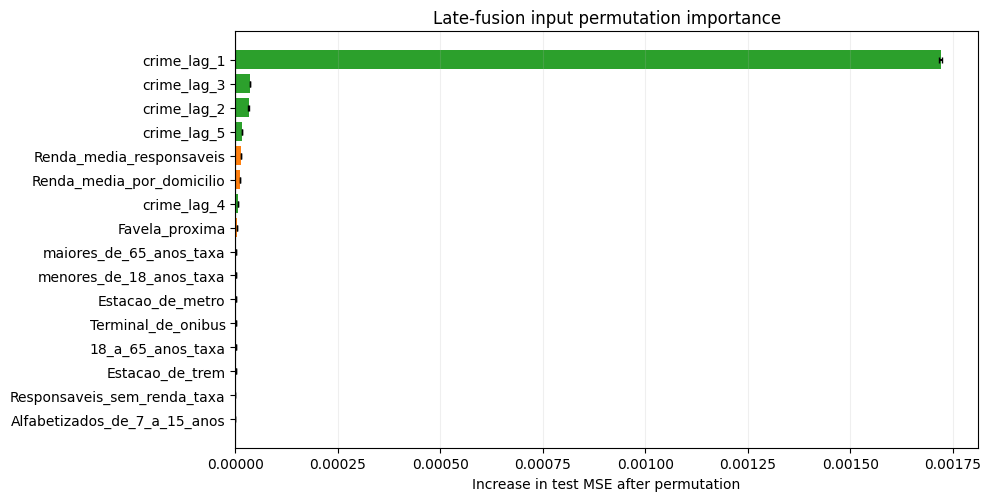

In [97]:
@torch.no_grad()
def late_permutation_importance(model,loader,device="cpu",static_names=None,repeats=3,random_seed=42):
    model.eval(); baseline=late_metrics["MSE"]; sample=next(iter(loader))
    static_dim,dynamic_dim=sample.x_static.shape[1],sample.x_dynamic.shape[1]
    if static_names is None or len(static_names)!=static_dim: static_names=[f"static_{i}" for i in range(static_dim)]
    dynamic_names=[f"crime_lag_{dynamic_dim-i}" for i in range(dynamic_dim)]
    rows=[]
    for modality,dim,names in [("static",static_dim,static_names),("dynamic",dynamic_dim,dynamic_names)]:
        for feature_index in range(dim):
            losses=[]
            for repeat in range(repeats):
                pred_all=[]; target_all=[]
                for step,batch in enumerate(loader):
                    batch=batch.to(device); xs=batch.x_static.clone(); xd=batch.x_dynamic.clone()
                    g=torch.Generator(device=device); g.manual_seed(random_seed+100000*(modality=="dynamic")+1000*feature_index+31*repeat+step)
                    permutation=torch.randperm(xs.shape[0],generator=g,device=device)
                    if modality=="static": xs[:,feature_index]=xs[permutation,feature_index]
                    else: xd[:,feature_index]=xd[permutation,feature_index]
                    prediction,_=model(xs,xd,batch.edge_index)
                    pred_all.append(prediction.cpu()); target_all.append(batch.y.float().view_as(prediction).cpu())
                prediction=torch.cat(pred_all).numpy(); target=torch.cat(target_all).numpy(); losses.append(float(np.mean((prediction-target)**2)))
            rows.append({"modality":modality,"feature":names[feature_index],"baseline_MSE":baseline,"permuted_MSE_mean":np.mean(losses),"permuted_MSE_std":np.std(losses,ddof=1) if repeats>1 else 0.0,"delta_MSE":np.mean(losses)-baseline})
    return pd.DataFrame(rows)

static_feature_names=list(static_dt.columns) if len(static_dt.columns)==S else None
late_permutation_table=late_permutation_importance(model,test_loader,"cpu",static_feature_names,3,seed)
display(late_permutation_table.sort_values("delta_MSE",ascending=False).head(15))
plot_df=late_permutation_table.sort_values("delta_MSE")
plt.figure(figsize=(10,max(5,0.32*len(plot_df)))); plt.barh(plot_df["feature"],plot_df["delta_MSE"],xerr=plot_df["permuted_MSE_std"],color=plot_df["modality"].map({"static":"tab:orange","dynamic":"tab:green"}),capsize=2)
plt.axvline(0,color="black"); plt.xlabel("Increase in test MSE after permutation"); plt.title("Late-fusion input permutation importance"); plt.grid(axis="x",alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder,"late_fusion_input_permutation.png"),dpi=300,bbox_inches="tight"); plt.show()
late_permutation_table.to_csv(os.path.join(output_folder,"late_fusion_input_permutation.csv"),index=False)


## K. Graph-structure reliance

Both modality encoders use GAT layers. Removing all edges tests whether the frozen late-fusion model functionally relies on graph propagation. Because this is an off-training-distribution intervention, a separately trained no-graph late-fusion baseline remains stronger evidence.

,graph_condition,MSE,RMSE,MAE,delta_MSE_vs_graph,relative_MSE_change_percent
0,Learned graph,0.001016,0.031867,0.017507,0.000000,0.0000
1,Edges removed,0.000071,0.008411,0.004040,-0.000945,-93.0338


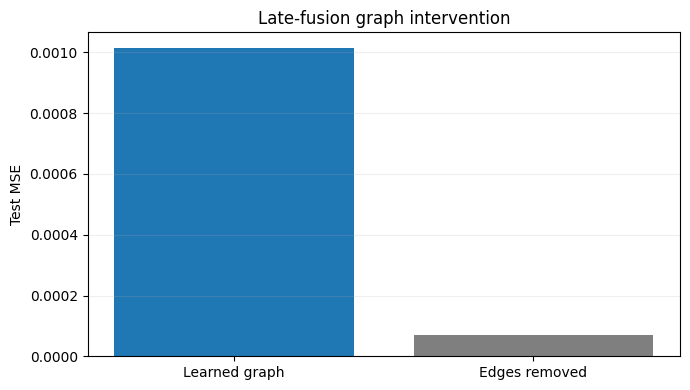

In [98]:
@torch.no_grad()
def evaluate_late_edges(model,loader,device="cpu",remove_edges=False):
    model.eval(); pred_all=[]; target_all=[]
    for batch in loader:
        batch=batch.to(device); edges=batch.edge_index
        if remove_edges: edges=torch.empty((2,0),dtype=torch.long,device=device)
        prediction,_=model(batch.x_static,batch.x_dynamic,edges)
        pred_all.append(prediction.cpu()); target_all.append(batch.y.float().view_as(prediction).cpu())
    prediction=torch.cat(pred_all).numpy(); target=torch.cat(target_all).numpy(); error=prediction-target; mse=float(np.mean(error**2))
    return {"MSE":mse,"RMSE":float(np.sqrt(mse)),"MAE":float(np.mean(np.abs(error)))}

late_graph_intervention=pd.DataFrame([
    {"graph_condition":"Learned graph",**evaluate_late_edges(model,test_loader,"cpu",False)},
    {"graph_condition":"Edges removed",**evaluate_late_edges(model,test_loader,"cpu",True)},
])
graph_baseline=late_graph_intervention.loc[late_graph_intervention.graph_condition=="Learned graph","MSE"].iloc[0]
late_graph_intervention["delta_MSE_vs_graph"]=late_graph_intervention["MSE"]-graph_baseline
late_graph_intervention["relative_MSE_change_percent"]=100*late_graph_intervention["delta_MSE_vs_graph"]/(graph_baseline+1e-12)
display(late_graph_intervention.round(6))
plt.figure(figsize=(7,4)); plt.bar(late_graph_intervention["graph_condition"],late_graph_intervention["MSE"],color=["tab:blue","tab:gray"])
plt.ylabel("Test MSE"); plt.title("Late-fusion graph intervention"); plt.grid(axis="y",alpha=0.2); plt.tight_layout(); plt.savefig(os.path.join(output_folder,"late_fusion_graph_intervention.png"),dpi=300,bbox_inches="tight"); plt.show()
late_graph_intervention.to_csv(os.path.join(output_folder,"late_fusion_graph_intervention.csv"),index=False)


## L. Time-cluster bootstrap confidence intervals

Complete test windows are resampled so nodes from the same time remain together. These intervals represent variation across test windows, not random initialization or training uncertainty. Matched multi-seed experiments are still required.

,quantity,estimate,bootstrap_ci95_low,bootstrap_ci95_high,bootstrap_std
0,MSE,0.001016,0.001003,0.001032,0.000007
1,MAE,0.017507,0.017398,0.017630,0.000058
2,static_effective_share,0.668859,0.668097,0.669661,0.000399
3,share_crime_spearman,-0.710117,-0.712724,-0.707293,0.001399


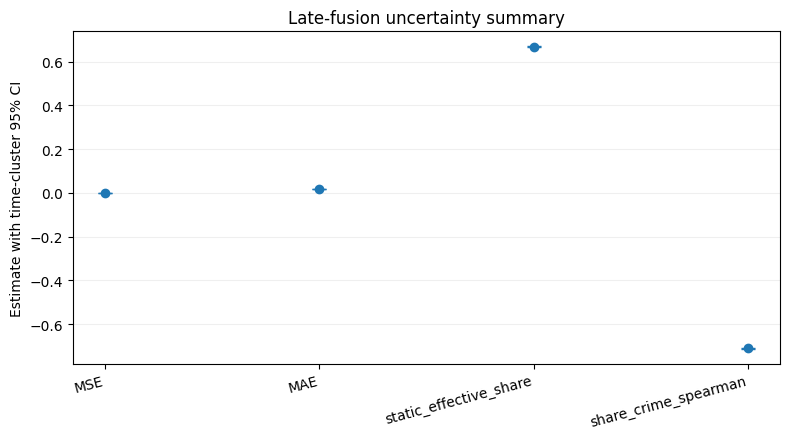

In [99]:
def late_cluster_bootstrap(frame,n_bootstrap=1000,random_seed=42):
    rng=np.random.default_rng(random_seed); clusters=frame["time_id"].drop_duplicates().to_numpy(); estimates=[]
    for _ in range(n_bootstrap):
        sampled=rng.choice(clusters,size=len(clusters),replace=True)
        boot=pd.concat([frame.loc[frame.time_id==c] for c in sampled],ignore_index=True)
        error=boot["prediction"]-boot["target_crime"]
        estimates.append({"MSE":np.mean(error**2),"MAE":np.mean(np.abs(error)),"static_effective_share":boot["static_effective_share"].mean(),"share_crime_spearman":association_stats_late(boot["input_crime"],boot["static_effective_share"])["spearman_rho"]})
    samples=pd.DataFrame(estimates)
    point={"MSE":late_metrics["MSE"],"MAE":late_metrics["MAE"],"static_effective_share":frame["static_effective_share"].mean(),"share_crime_spearman":association_stats_late(frame["input_crime"],frame["static_effective_share"])["spearman_rho"]}
    summary=pd.DataFrame([{"quantity":col,"estimate":point[col],"bootstrap_ci95_low":samples[col].quantile(.025),"bootstrap_ci95_high":samples[col].quantile(.975),"bootstrap_std":samples[col].std(ddof=1)} for col in samples.columns])
    return summary,samples

late_bootstrap_summary,late_bootstrap_samples=late_cluster_bootstrap(late_frame,1000,seed)
display(late_bootstrap_summary.round(6))
x=np.arange(len(late_bootstrap_summary)); lower=late_bootstrap_summary["estimate"]-late_bootstrap_summary["bootstrap_ci95_low"]; upper=late_bootstrap_summary["bootstrap_ci95_high"]-late_bootstrap_summary["estimate"]
plt.figure(figsize=(8,4.5)); plt.errorbar(x,late_bootstrap_summary["estimate"],yerr=np.vstack([lower,upper]),fmt="o",capsize=5,linewidth=2)
plt.xticks(x,late_bootstrap_summary["quantity"],rotation=15,ha="right"); plt.ylabel("Estimate with time-cluster 95% CI"); plt.title("Late-fusion uncertainty summary"); plt.grid(axis="y",alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder,"late_fusion_bootstrap_ci.png"),dpi=300,bbox_inches="tight"); plt.show()
late_bootstrap_summary.to_csv(os.path.join(output_folder,"late_fusion_bootstrap_ci.csv"),index=False)


## M. Robust embedding projection

The existing notebook already visualizes the concatenated late-fusion embedding. This version uses the first complete test window and colors nodes by the continuous future crime target. t-SNE describes local visual structure only; it is not a prediction or clustering metric.

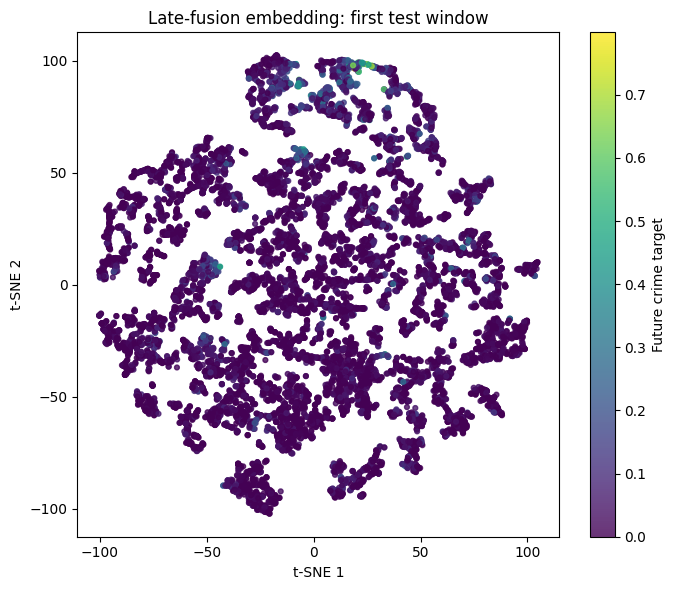

In [100]:
from sklearn.manifold import TSNE
embedding_first=late_details["z_fused"][:len(late_details["targets_per_time"][0])]
target_first=late_details["targets_per_time"][0]
if embedding_first.shape[0]>=3:
    perplexity=min(30,max(2,(embedding_first.shape[0]-1)//3))
    late_embedding_2d=TSNE(n_components=2,perplexity=perplexity,init="pca",learning_rate="auto",random_state=seed).fit_transform(embedding_first)
    plt.figure(figsize=(7,6)); scatter=plt.scatter(late_embedding_2d[:,0],late_embedding_2d[:,1],c=target_first,cmap="viridis",s=12,alpha=0.8)
    plt.colorbar(scatter,label="Future crime target"); plt.title("Late-fusion embedding: first test window"); plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.tight_layout()
    plt.savefig(os.path.join(output_folder,"late_fusion_embedding_tsne_robust.png"),dpi=300,bbox_inches="tight"); plt.show()
    pd.DataFrame({"tsne_1":late_embedding_2d[:,0],"tsne_2":late_embedding_2d[:,1],"target_crime":target_first}).to_csv(os.path.join(output_folder,"late_fusion_embedding_tsne_robust.csv"),index=False)
else: print("At least three nodes are required for t-SNE.")


## N. Exportable summary for M11, GMU, GMU–GNN and late-fusion comparison

Unavailable gate fields are recorded as missing values rather than being manufactured. Prediction, ablation, effective branch contribution, permutation, graph intervention and bootstrap quantities remain directly reportable.

In [101]:
dynamic_removed=late_branch_interventions.query("intervention == 'Dynamic branch removed'").iloc[0]
static_removed=late_branch_interventions.query("intervention == 'Static branch removed'").iloc[0]
dynamic_shuffled=late_branch_interventions.query("intervention == 'Dynamic branch shuffled'").iloc[0]
static_shuffled=late_branch_interventions.query("intervention == 'Static branch shuffled'").iloc[0]
edge_removed=late_graph_intervention.query("graph_condition == 'Edges removed'").iloc[0]
input_assoc=late_fusion_crime_associations.query("crime_variable == 'input_crime'").iloc[0]

late_fusion_model_summary=pd.DataFrame([{
    "model":"M7 late fusion","uses_graph":True,"fusion_location":"after_separate_graph_encoders","has_modality_gate":False,
    "test_MSE":late_metrics["MSE"],"test_RMSE":late_metrics["RMSE"],"test_MAE":late_metrics["MAE"],"test_R2":late_metrics["R2"],
    "static_only_MSE":dynamic_removed["MSE"],"dynamic_only_MSE":static_removed["MSE"],
    "static_gate_mean":np.nan,"gate_entropy":np.nan,"gate_input_crime_spearman":np.nan,
    "effective_static_proportion":late_frame["static_effective_share"].mean(),
    "effective_share_input_crime_spearman":input_assoc["spearman_rho"],
    "static_branch_shuffle_delta_MSE":static_shuffled["MSE"]-late_metrics["MSE"],
    "dynamic_branch_shuffle_delta_MSE":dynamic_shuffled["MSE"]-late_metrics["MSE"],
    "edges_removed_delta_MSE":edge_removed["MSE"]-late_metrics["MSE"],
    "self_neighbor_analysis_available":False,
}])
display(late_fusion_model_summary.T)
late_fusion_model_summary.to_csv(os.path.join(output_folder,"late_fusion_professional_summary.csv"),index=False)


,0
model,M7 late fusion
uses_graph,True
fusion_location,after_separate_graph_encoders
has_modality_gate,False
test_MSE,0.001016
test_RMSE,0.031867
test_MAE,0.017507
test_R2,0.649974
static_only_MSE,0.004393
dynamic_only_MSE,0.004555


## Interpretation framework

1. Report predictive metrics across identical chronological splits and matched seeds.
2. Call this architecture late fusion because separately graph-encoded branches are concatenated only before the final predictor.
3. Do not call effective branch shares “gates”; no learned probability gate exists.
4. Compare raw embedding norms with weighted branch outputs. The latter are closer to the prediction mechanism.
5. Use input ablation and latent-branch intervention together; neither replaces independently trained unimodal baselines.
6. Use branch shuffling as a case-assignment faithfulness test.
7. Use feature permutation to return from latent branches to named socioeconomic features and temporal lags.
8. Use edge removal to test graph reliance, while acknowledging its off-distribution nature.
9. Treat time-bootstrap intervals and multi-seed variation as different uncertainty sources.
10. M11’s self/neighbor gate separation is an additional architectural capability and is not a score that can be assigned to late fusion.